# Airline Customer Satisfaction Modeling

This notebook builds a complete, portfolio-ready machine learning workflow on **Fact_Satisfaction_clean.csv**.

## Goals
- Predict customer satisfaction using **all relevant features detected dynamically**
- Compare Logistic Regression, Random Forest, and XGBoost/LightGBM
- Add feature explainability with model importances and SHAP
- Analyze delay impact (departure and arrival delays)
- Segment customers with KMeans clustering
- Create and analyze a churn proxy label

The notebook is designed to adapt if the dataset schema changes (extra columns, new categories, binary/multiclass target).

In [1]:
# Run this once if some libraries are missing in your environment.
import sys, subprocess, importlib


def pip_install(args):
    cmd = [sys.executable, "-m", "pip"] + args
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        if result.stdout:
            print(result.stdout)
        if result.stderr:
            print(result.stderr)
        raise RuntimeError(f"pip failed with exit code {result.returncode}")


def ensure_import(pkg, import_name):
    try:
        importlib.import_module(import_name)
        print(f"{pkg} already installed")
        return True
    except Exception:
        return False


packages = {
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scikit-learn": "sklearn",
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
    "shap": "shap",
    "ydata-profiling": "ydata_profiling",
}

for pkg, import_name in packages.items():
    if ensure_import(pkg, import_name):
        continue

    print(f"Installing {pkg} ...")
    try:
        if pkg == "matplotlib":
            # Clean reinstall fixes broken backend registry imports
            try:
                pip_install(["uninstall", "-y", "matplotlib"])
            except Exception:
                pass
            try:
                pip_install(["install", "--no-cache-dir", "--force-reinstall", "matplotlib"])
            except Exception:
                print("Retrying matplotlib with --user...")
                pip_install(["install", "--user", "--no-cache-dir", "--force-reinstall", "matplotlib"])
        else:
            pip_install(["install", pkg])
    except Exception as e:
        print(f"⚠️  Failed to install {pkg}: {e}")

print("Dependency check complete.")

matplotlib already installed
seaborn already installed
scikit-learn already installed
xgboost already installed
lightgbm already installed


c:\Users\achre\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap already installed
Installing ydata-profiling ...
Dependency check complete.


In [2]:
# Core libraries
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# Optional gradient boosting backends
GBM_BACKEND = None
try:
    from xgboost import XGBClassifier
    GBM_BACKEND = "xgboost"
except Exception:
    try:
        from lightgbm import LGBMClassifier
        GBM_BACKEND = "lightgbm"
    except Exception:
        GBM_BACKEND = None

# Explainability (optional)
try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

# display() shim: works in Jupyter; falls back to print() in plain Python
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

print(f"Gradient boosting backend: {GBM_BACKEND if GBM_BACKEND else 'none available'}")
print(f"SHAP available: {SHAP_AVAILABLE}")
print("Libraries loaded.")


Gradient boosting backend: xgboost
SHAP available: True
Libraries loaded.


## 1) Data Loading and Dynamic Schema Detection

In [3]:
# Resolve dataset path dynamically
candidate_paths = [
    Path("Fact_Satisfaction_clean.csv"),
    Path("./Fact_Satisfaction_clean.csv"),
    Path("../Fact_Satisfaction_clean.csv"),
    Path("../../04_Data_Cleaned/Fact_Satisfaction_clean.csv"),
    Path("../../04_Data_Cleaned/curated_dw/Fact_Satisfaction_clean.csv"),
]

csv_path = None
for p in candidate_paths:
    if p.exists():
        csv_path = p.resolve()
        break

if csv_path is None:
    raise FileNotFoundError("Could not locate Fact_Satisfaction_clean.csv.")

df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path}")
print(f"Shape: {df.shape}")

def detect_target_column(columns):
    candidates = [c for c in columns if c.lower() in {"satisfaction", "target", "label", "y"}]
    if candidates:
        return candidates[0]

    contains = [c for c in columns if "satisf" in c.lower()]
    if contains:
        return contains[0]

    raise ValueError("No obvious target column found. Please add a target-like column (e.g., satisfaction).")

target_col = detect_target_column(df.columns)
print(f"Detected target column: {target_col}")

display(df.head(3))
display(df.dtypes.to_frame("dtype").T)

Loaded: C:\Users\achre\Downloads\Esprit\DL\SkyInsight\07_ML\Airline Customer Satisfaction\Fact_Satisfaction_clean.csv
Shape: (129879, 26)
Detected target column: Neutral or Dissatisfied


,1,1.1,Male,48,First-time,Business,Business.1,821,2,0,...,5,2.1,5.1,5.2,5.3,3.5,5.4,5.5,Neutral or Dissatisfied,0.1
0,2,2,Female,35,Returning,Business,Business,821,26,0,...,4,5,5,3,5,2,5,5,Satisfied,1
1,3,3,Male,41,Returning,Business,Business,853,0,0,...,5,3,5,5,3,4,3,3,Satisfied,1
2,4,4,Male,50,Returning,Business,Business,1905,0,0,...,5,5,4,4,5,2,5,5,Satisfied,1


,1,1.1,Male,48,First-time,Business,Business.1,821,2,0,...,5,2.1,5.1,5.2,5.3,3.5,5.4,5.5,Neutral or Dissatisfied,0.1
dtype,int64,int64,object,int64,object,object,object,int64,int64,int64,...,int64,int64,int64,int64,int64,int64,int64,int64,object,int64


## 2) Data Profiling and EDA
This section profiles all columns using **ydata-profiling**, checks missingness, and visualizes core distributions and correlations.

ydata-profiling skipped: No module named 'pkg_resources'
Total columns: 26
Numeric columns: 21
Categorical columns: 5


,missing_count,missing_pct
1,0,0.0
1.1,0,0.0
Male,0,0.0
48,0,0.0
First-time,0,0.0
Business,0,0.0
Business.1,0,0.0
821,0,0.0
2,0,0.0
0,0,0.0


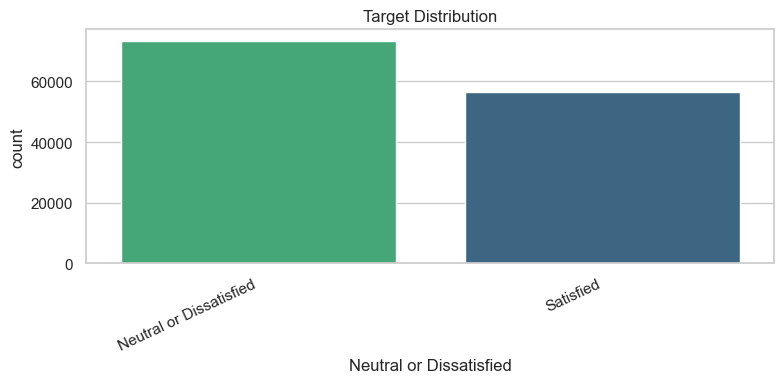

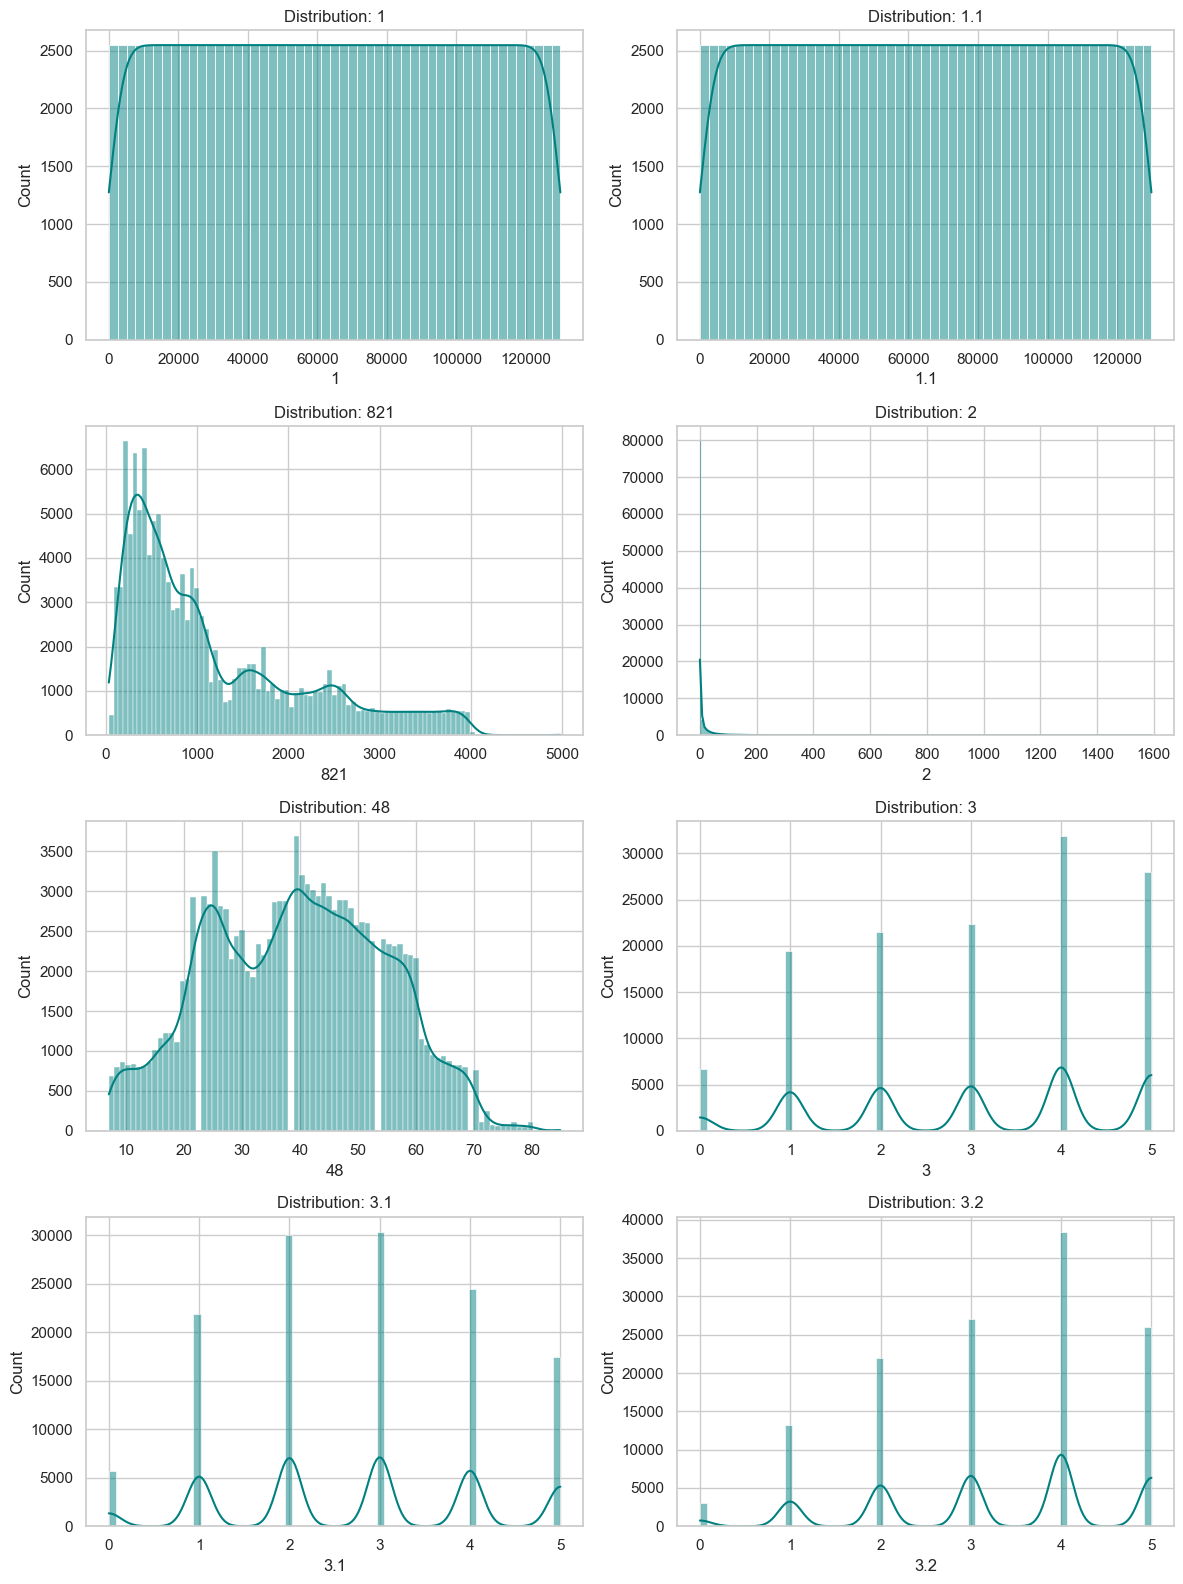

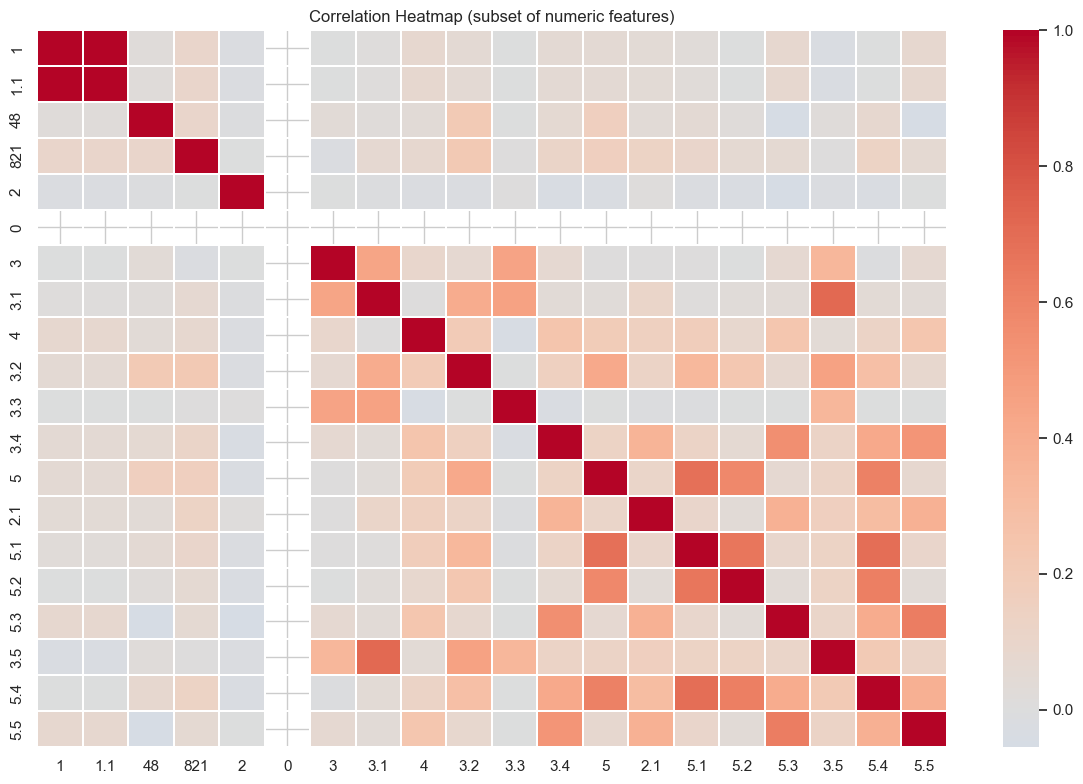

In [4]:
# Quick automated profiling (ydata-profiling)
try:
    from ydata_profiling import ProfileReport
    profile = ProfileReport(df, title="Airline Customer Satisfaction Profiling", minimal=True)
    display(profile.to_notebook_iframe())
except Exception as e:
    print(f"ydata-profiling skipped: {e}")

# Identify column families dynamically
all_columns = df.columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in all_columns if c not in numeric_cols]

print(f"Total columns: {len(all_columns)}")
print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
display(missing_table.head(20))

# Target distribution
# FIX: pass hue=target_col + legend=False to avoid seaborn >=0.13 FutureWarning
plt.figure(figsize=(8, 4))
target_order = df[target_col].astype(str).value_counts().index
sns.countplot(data=df, x=target_col, hue=target_col, order=target_order,
              palette="viridis", legend=False)
plt.title("Target Distribution")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# Numeric distributions (top up to 8 with largest variance)
usable_numeric = [c for c in numeric_cols if c != target_col]
if usable_numeric:
    variances = df[usable_numeric].var().sort_values(ascending=False)
    top_num = variances.head(min(8, len(variances))).index.tolist()

    n = len(top_num)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))
    # FIX: np.atleast_1d + ravel handles both single-row and multi-row grids safely
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(top_num):
        sns.histplot(df[col], kde=True, ax=axes[i], color="teal")
        axes[i].set_title(f"Distribution: {col}")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# Correlation heatmap for top numeric columns
if usable_numeric:
    top_corr_cols = usable_numeric[:min(20, len(usable_numeric))]
    corr = df[top_corr_cols].corr()

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
    plt.title("Correlation Heatmap (subset of numeric features)")
    plt.tight_layout()
    plt.show()


## 3) Preprocessing and Feature Engineering
- Handles missing values automatically
- Encodes categorical variables
- Engineers delay features (`total_delay`, `delay_flag`)
- Detects and removes likely identifier columns

In [5]:
df_model = df.copy()

# Utility: find columns by keyword
def find_col_by_keywords(columns, include_keywords):
    include_keywords = [k.lower() for k in include_keywords]
    matches = [c for c in columns if any(k in c.lower() for k in include_keywords)]
    return matches

# Delay columns (dynamic)
dep_candidates = find_col_by_keywords(df_model.columns, ["departure_delay", "dep_delay", "departure"])
arr_candidates = find_col_by_keywords(df_model.columns, ["arrival_delay", "arr_delay", "arrival"])

dep_col = dep_candidates[0] if dep_candidates else None
arr_col = arr_candidates[0] if arr_candidates else None

# Convert candidate delays to numeric where possible
for c in [dep_col, arr_col]:
    if c is not None:
        df_model[c] = pd.to_numeric(df_model[c], errors="coerce")

# Feature engineering around delays
if dep_col is not None and arr_col is not None:
    df_model["total_delay"] = df_model[dep_col].fillna(0) + df_model[arr_col].fillna(0)
elif dep_col is not None:
    df_model["total_delay"] = df_model[dep_col].fillna(0)
elif arr_col is not None:
    df_model["total_delay"] = df_model[arr_col].fillna(0)
else:
    df_model["total_delay"] = 0

delay_threshold = df_model["total_delay"].quantile(0.75)
df_model["delay_flag"] = (df_model["total_delay"] > delay_threshold).astype(int)

# Optional interaction feature if age and distance are present
age_cols = find_col_by_keywords(df_model.columns, ["age"])
dist_cols = find_col_by_keywords(df_model.columns, ["distance", "flight_distance"])
if age_cols and dist_cols:
    age_col = age_cols[0]
    dist_col = dist_cols[0]
    df_model["age_distance_interaction"] = (
        pd.to_numeric(df_model[age_col], errors="coerce").fillna(0)
        * pd.to_numeric(df_model[dist_col], errors="coerce").fillna(0)
    )

# Detect likely ID-like columns to drop from features
id_like_cols = []
for c in df_model.columns:
    if c == target_col:
        continue

    c_lower = c.lower()
    uniqueness_ratio = df_model[c].nunique(dropna=True) / max(1, len(df_model))
    if ("id" in c_lower and c_lower != "class") or uniqueness_ratio > 0.98:
        id_like_cols.append(c)

print("Detected delay columns:", {"departure": dep_col, "arrival": arr_col})
print(f"Engineered features added: {[c for c in ['total_delay', 'delay_flag', 'age_distance_interaction'] if c in df_model.columns]}")
print(f"Potential ID-like columns to drop: {id_like_cols[:10]}{' ...' if len(id_like_cols) > 10 else ''}")

Detected delay columns: {'departure': None, 'arrival': None}
Engineered features added: ['total_delay', 'delay_flag']
Potential ID-like columns to drop: ['1', '1.1']


## 4) Build Modeling Matrix and Feature Selection
Feature selection is performed after encoding using model-based importance (Random Forest) to keep the most informative transformed features.

In [6]:
# Prepare X/y
drop_cols = list(set(id_like_cols + [target_col]))
X_raw = df_model.drop(columns=drop_cols, errors="ignore")
y_raw = df_model[target_col].astype(str)

# Label encode target for robust multiclass support
label_enc = LabelEncoder()
y = label_enc.fit_transform(y_raw)
class_names = label_enc.classes_.tolist()
n_classes = len(class_names)

print(f"Target classes ({n_classes}): {class_names}")

# Train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# Dynamic column typing after feature engineering
train_num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
train_cat_cols = [c for c in X_train_raw.columns if c not in train_num_cols]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# FIX: sparse_threshold=0.0 forces dense output from ColumnTransformer,
# avoiding sparse matrix indexing issues downstream
preprocessor = ColumnTransformer([
    ("num", num_pipe, train_num_cols),
    ("cat", cat_pipe, train_cat_cols),
], sparse_threshold=0.0)

X_train_full = preprocessor.fit_transform(X_train_raw)
X_test_full = preprocessor.transform(X_test_raw)

# FIX: ensure dense numpy arrays (sparse_threshold=0 should already do this,
# but we guard with np.asarray for safety)
X_train_full = np.asarray(X_train_full)
X_test_full = np.asarray(X_test_full)

feature_names_full = preprocessor.get_feature_names_out()

# Model-based feature selection
selector_model = RandomForestClassifier(
    n_estimators=350,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
selector_model.fit(X_train_full, y_train)
importances = selector_model.feature_importances_

# Keep a dynamic top-k set
n_total_features = len(feature_names_full)
top_k = min(max(30, int(n_total_features * 0.35)), n_total_features)
# FIX: cast to plain Python int list so numpy fancy-indexing works reliably
selected_idx = np.argsort(importances)[::-1][:top_k]
selected_features = feature_names_full[selected_idx]

X_train_sel = X_train_full[:, selected_idx]
X_test_sel = X_test_full[:, selected_idx]

feature_selection_df = pd.DataFrame({
    "feature": feature_names_full,
    "importance": importances
}).sort_values("importance", ascending=False)

print(f"Raw model features: {n_total_features}")
print(f"Selected features: {len(selected_features)}")
display(feature_selection_df.head(20))


Target classes (2): ['Neutral or Dissatisfied', 'Satisfied']
Raw model features: 30
Selected features: 30


,feature,importance
18,num__0.1,0.527301
7,num__3.2,0.090367
15,num__3.5,0.056625
27,cat__Business.1_Business,0.046496
25,cat__Business_Business,0.046484
26,cat__Business_Personal,0.040500
16,num__5.4,0.032866
28,cat__Business.1_Economy,0.028304
10,num__5,0.019365
5,num__3.1,0.015652


## 5) Model Training
Models trained on selected features:
- Logistic Regression (baseline)
- Random Forest
- XGBoost (or LightGBM fallback)

In [7]:
models = {}

models["Logistic Regression"] = LogisticRegression(
    max_iter=3000,
    solver="saga",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

models["Random Forest"] = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

if GBM_BACKEND == "xgboost":
    models["XGBoost"] = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob" if n_classes > 2 else "binary:logistic",
        eval_metric="mlogloss" if n_classes > 2 else "logloss",
        random_state=42,
        n_jobs=-1
    )
elif GBM_BACKEND == "lightgbm":
    models["LightGBM"] = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42
    )

trained_models = {}
for name, model in models.items():
    print(f"Training {name} ...")
    model.fit(X_train_sel, y_train)
    trained_models[name] = model

print("All models trained.")

Training Logistic Regression ...
Training Random Forest ...
Training XGBoost ...
All models trained.


## 6) Evaluation
Metrics: Accuracy, Precision, Recall, F1, ROC-AUC (when applicable), and confusion matrices.

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
2,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000


Best model by F1: Logistic Regression


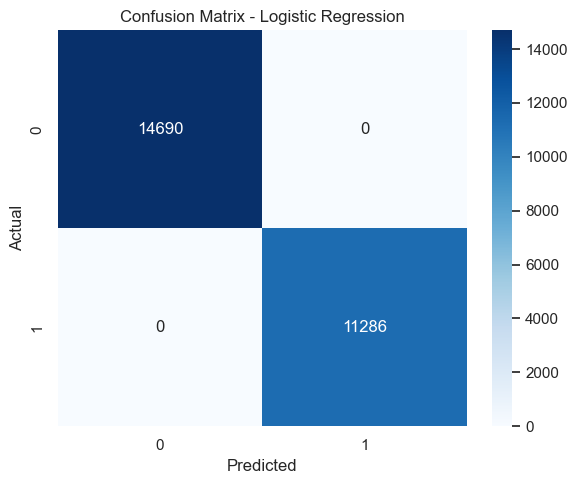

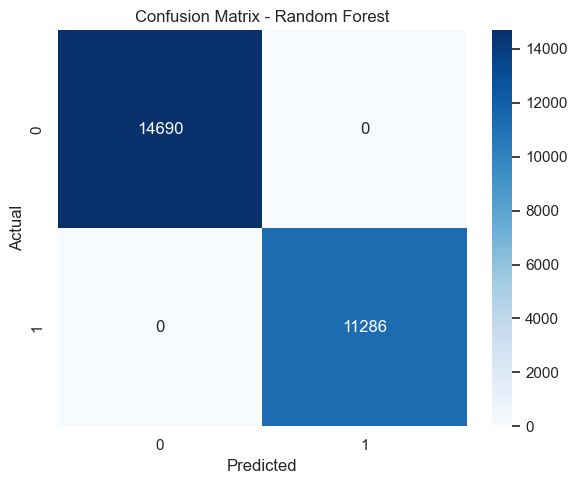

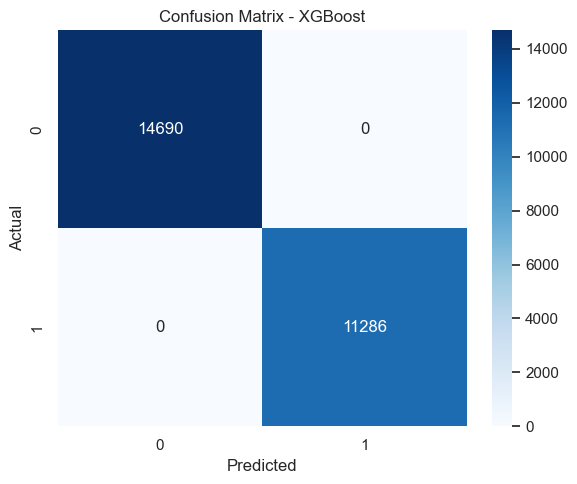

                         precision    recall  f1-score   support

Neutral or Dissatisfied       1.00      1.00      1.00     14690
              Satisfied       1.00      1.00      1.00     11286

               accuracy                           1.00     25976
              macro avg       1.00      1.00      1.00     25976
           weighted avg       1.00      1.00      1.00     25976



In [8]:
from sklearn.preprocessing import label_binarize

def evaluate_model(name, model, X_test, y_test, n_classes):
    y_pred = model.predict(X_test)

    avg = "binary" if n_classes == 2 else "weighted"
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average=avg, zero_division=0),
        "recall": recall_score(y_test, y_pred, average=avg, zero_division=0),
        "f1": f1_score(y_test, y_pred, average=avg, zero_division=0),
    }

    roc_auc = np.nan
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        try:
            if n_classes == 2:
                roc_auc = roc_auc_score(y_test, y_proba[:, 1])
            else:
                y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
                roc_auc = roc_auc_score(y_test_bin, y_proba, multi_class="ovr", average="weighted")
        except Exception:
            roc_auc = np.nan

    metrics["roc_auc"] = roc_auc
    return metrics, y_pred

results = []
predictions = {}

for name, model in trained_models.items():
    m, y_hat = evaluate_model(name, model, X_test_sel, y_test, n_classes)
    results.append(m)
    predictions[name] = y_hat

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)

# Pandas Styler requires jinja2. Fallback to plain DataFrame display if unavailable.
try:
    display(results_df.style.format({
        "accuracy": "{:.4f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}",
        "roc_auc": "{:.4f}"
    }))
except Exception as e:
    print(f"Styler unavailable ({e}). Showing plain results table.")
    display(results_df.round(4))

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
print(f"Best model by F1: {best_model_name}")

# Confusion matrices
for name, y_hat in predictions.items():
    cm = confusion_matrix(y_test, y_hat)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Detailed report for best model
best_pred = predictions[best_model_name]
print(classification_report(y_test, best_pred, target_names=class_names, zero_division=0))

## 7) Feature Importance and Explainability
This section combines built-in importances/coefficients with SHAP analysis for deeper insight.

,feature,importance
10,num__0.1,3.325500
4,cat__Business_Personal,0.231806
5,cat__First-time_First-time,0.173133
15,num__3.2,0.163850
1,cat__Business.1_Economy,0.135943
18,num__3.5,0.090312
3,cat__Business_Business,0.087021
7,cat__Male_Female,0.083743
8,cat__Male_Male,0.072808
25,num__5.4,0.068483


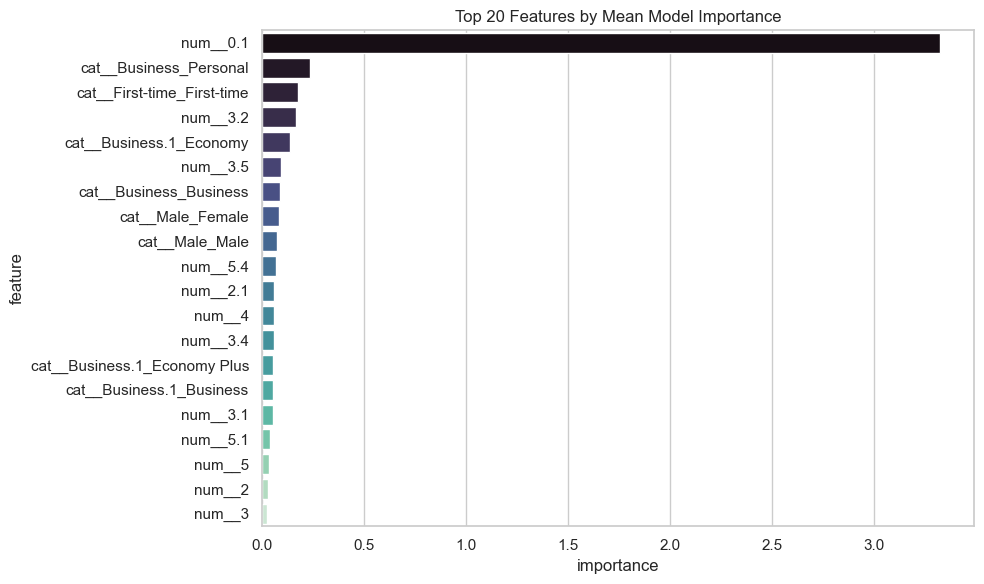

Running SHAP with: XGBoost


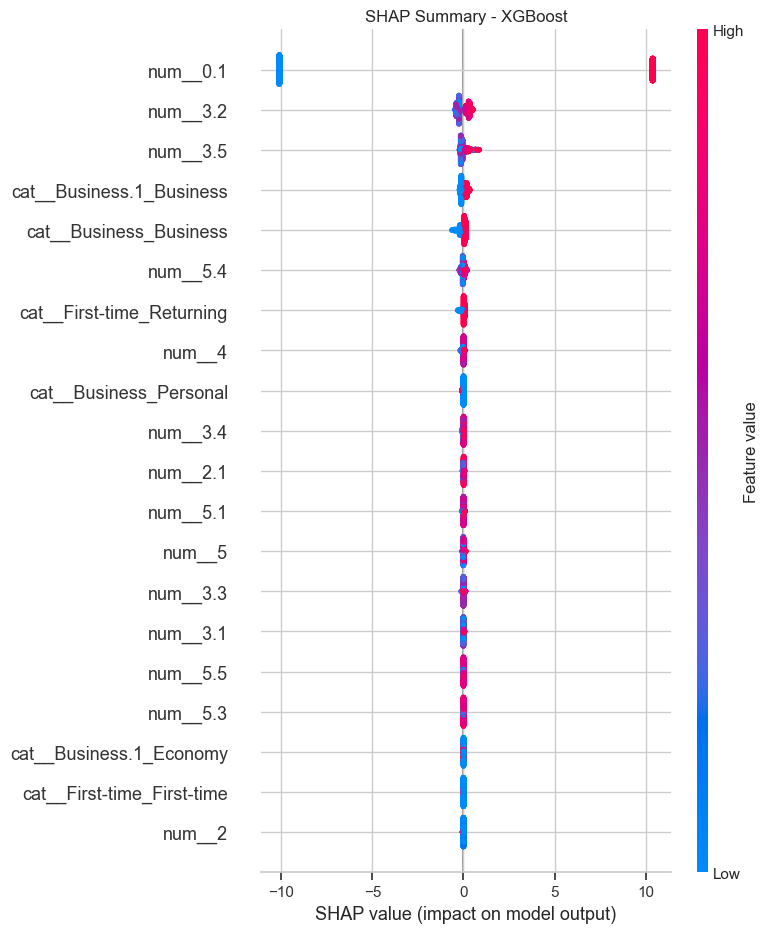

In [9]:
# Built-in importance extraction
importance_rows = []

for name, model in trained_models.items():
    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
    elif hasattr(model, "coef_"):
        coef = model.coef_
        imp = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef).ravel()
    else:
        continue

    temp = pd.DataFrame({
        "feature": selected_features,
        "importance": imp,
        "model": name
    })
    importance_rows.append(temp)

importance_df = pd.concat(importance_rows, ignore_index=True) if importance_rows else pd.DataFrame()

if not importance_df.empty:
    top_global = (
        importance_df
        .groupby("feature", as_index=False)["importance"]
        .mean()
        .sort_values("importance", ascending=False)
    )

    display(top_global.head(25))

    plt.figure(figsize=(10, 6))
    # FIX: add hue="feature" + legend=False to avoid seaborn >=0.13 FutureWarning
    sns.barplot(
        data=top_global.head(20),
        x="importance",
        y="feature",
        hue="feature",
        palette="mako",
        legend=False
    )
    plt.title("Top 20 Features by Mean Model Importance")
    plt.tight_layout()
    plt.show()

# SHAP on a tree-based model when available
# FIX: guard with SHAP_AVAILABLE flag
tree_model_name = None
for candidate in ["XGBoost", "LightGBM", "Random Forest"]:
    if candidate in trained_models:
        tree_model_name = candidate
        break

if tree_model_name is not None and SHAP_AVAILABLE:
    tree_model = trained_models[tree_model_name]
    print(f"Running SHAP with: {tree_model_name}")

    # Sample for efficient SHAP computation
    shap_n = min(2000, X_train_sel.shape[0])
    rng = np.random.default_rng(42)
    idx = rng.choice(X_train_sel.shape[0], size=shap_n, replace=False)
    # FIX: ensure dense array for SHAP compatibility
    X_shap = np.asarray(X_train_sel[idx])

    try:
        explainer = shap.TreeExplainer(tree_model)
        shap_values = explainer.shap_values(X_shap)

        plt.figure()
        shap.summary_plot(shap_values, X_shap, feature_names=selected_features, show=False)
        plt.title(f"SHAP Summary - {tree_model_name}")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"SHAP summary plot could not be generated: {e}")
elif tree_model_name is not None:
    print("SHAP not installed; skipping SHAP analysis. Install with: pip install shap")
else:
    print("No tree-based model available for SHAP in current environment.")


## 8) Delay Impact Modeling
Focused analysis on departure and arrival delay while keeping full-model context.

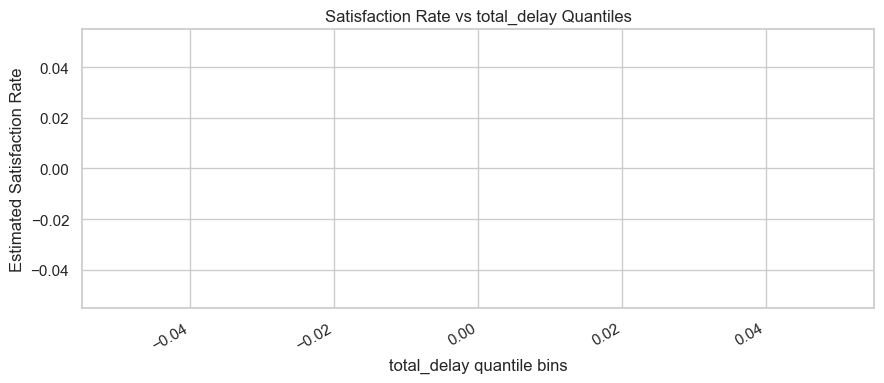

Delay-related selected transformed features: 2


,delay_related_feature
0,num__delay_flag
1,num__total_delay


In [10]:
# Build a binary satisfaction signal when possible (for intuitive delay analysis)
target_text = y_raw.str.lower()
positive_tokens = ["satisfied", "satisfaction", "happy", "yes", "1", "true"]
negative_tokens = ["dissatisfied", "unsatisfied", "neutral or dissatisfied", "no", "0", "false"]

pos_mask = target_text.apply(lambda x: any(t in x for t in positive_tokens))
neg_mask = target_text.apply(lambda x: any(t in x for t in negative_tokens))

if pos_mask.sum() + neg_mask.sum() >= int(0.6 * len(df_model)):
    sat_binary = pos_mask.astype(int)
else:
    # fallback: majority class as positive reference
    majority_class = y_raw.value_counts().index[0]
    sat_binary = (y_raw == majority_class).astype(int)

df_delay = df_model.copy()
df_delay["satisfaction_binary"] = sat_binary.values

delay_cols_present = [c for c in [dep_col, arr_col, "total_delay"] if c is not None and c in df_delay.columns]

for dcol in delay_cols_present:
    series = pd.to_numeric(df_delay[dcol], errors="coerce")
    if series.notna().sum() < 10:
        continue

    # Quantile bins for stable aggregation
    bin_col = "delay_bin"
    df_plot = pd.DataFrame({
        dcol: series,
        "satisfaction_binary": df_delay["satisfaction_binary"]
    }).dropna()
    df_plot[bin_col] = pd.qcut(df_plot[dcol], q=5, duplicates="drop")

    agg = df_plot.groupby(bin_col, observed=False)["satisfaction_binary"].mean().reset_index()
    agg[bin_col] = agg[bin_col].astype(str)

    plt.figure(figsize=(9, 4))
    sns.lineplot(data=agg, x=bin_col, y="satisfaction_binary", marker="o", color="crimson")
    plt.title(f"Satisfaction Rate vs {dcol} Quantiles")
    plt.xlabel(f"{dcol} quantile bins")
    plt.ylabel("Estimated Satisfaction Rate")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# Highlight delay features in selected set
delay_feature_hits = [f for f in selected_features if "delay" in f.lower() or "arrival" in f.lower() or "departure" in f.lower()]
print(f"Delay-related selected transformed features: {len(delay_feature_hits)}")
display(pd.DataFrame({"delay_related_feature": delay_feature_hits}).head(30))

## 9) Customer Segmentation (KMeans)
Clustering uses selected transformed features and chooses k with an elbow curve.

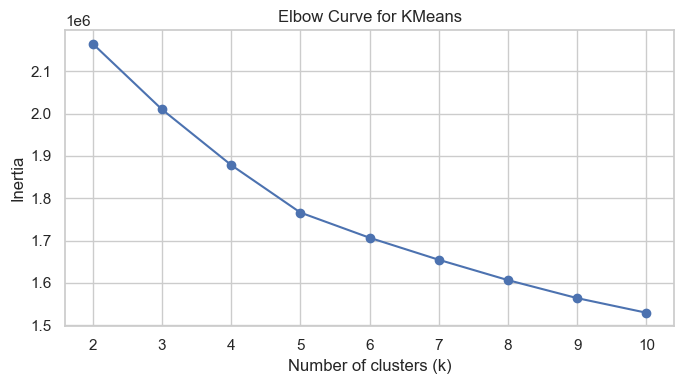

Selected k: 7


,cluster,customers,satisfaction_rate,avg_total_delay
0,0,22103,1.0,0.0
1,1,17170,1.0,0.0
2,2,17723,1.0,0.0
3,3,20030,1.0,0.0
4,4,24595,1.0,0.0
5,5,3009,1.0,0.0
6,6,25249,1.0,0.0


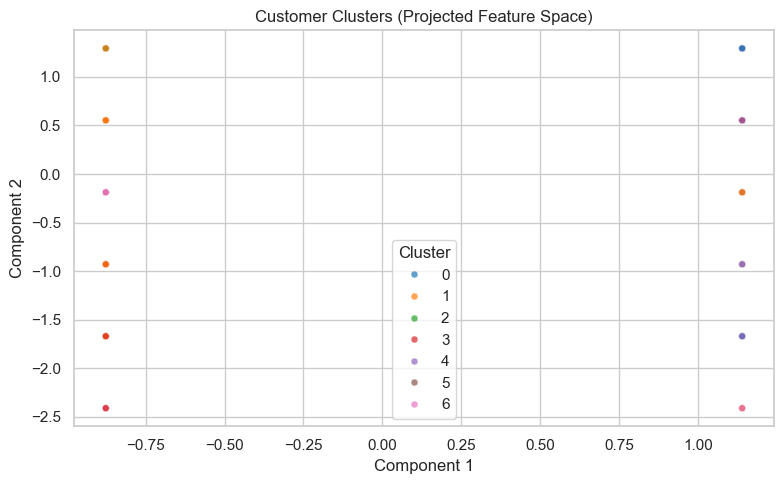

In [11]:
from scipy import sparse

# Transform full dataset using training preprocessor and selected features
X_all_full = preprocessor.transform(X_raw)
X_all_sel = X_all_full[:, selected_idx]

# Dense embedding for robust KMeans on possibly sparse matrices
if sparse.issparse(X_all_sel):
    n_comp = min(30, X_all_sel.shape[1] - 1) if X_all_sel.shape[1] > 1 else 1
    svd = TruncatedSVD(n_components=max(1, n_comp), random_state=42)
    X_cluster = svd.fit_transform(X_all_sel)
else:
    X_cluster = np.asarray(X_all_sel)

# Elbow method
k_values = list(range(2, 11))
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Curve for KMeans")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

# Simple elbow heuristic: largest second derivative
if len(inertias) >= 3:
    second_diff = np.diff(inertias, n=2)
    best_k = k_values[np.argmin(second_diff) + 1]
else:
    best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_cluster)

df_seg = df_model.copy()
df_seg["cluster"] = clusters
df_seg["satisfaction_binary"] = sat_binary.values

print(f"Selected k: {best_k}")

cluster_summary = df_seg.groupby("cluster").agg(
    customers=("cluster", "size"),
    satisfaction_rate=("satisfaction_binary", "mean"),
    avg_total_delay=("total_delay", "mean"),
).reset_index()
display(cluster_summary)

# 2D visualization with SVD projection
if X_cluster.shape[1] >= 2:
    plot_x = X_cluster[:, 0]
    plot_y = X_cluster[:, 1]
else:
    plot_x = X_cluster[:, 0]
    plot_y = np.zeros_like(plot_x)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=plot_x, y=plot_y, hue=clusters, palette="tab10", s=25, alpha=0.7)
plt.title("Customer Clusters (Projected Feature Space)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## 10) Churn Proxy Construction and Analysis
A churn-like proxy is created from dissatisfaction and delay stress signals, then summarized for business targeting.

Estimated churn proxy rate: 56.55%


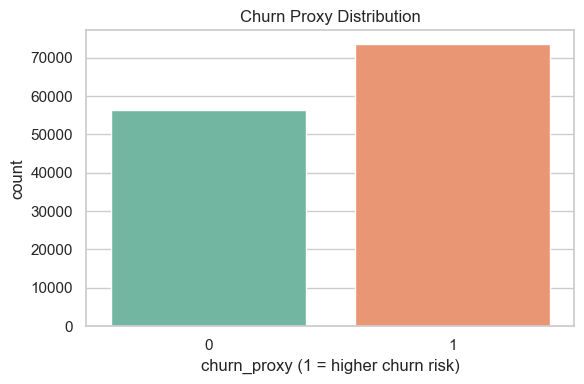

,cluster,churn_proxy
1,1,0.967618
6,6,0.863519
3,3,0.829056
2,2,0.810021
5,5,0.691924
4,4,0.064566
0,0,0.018188


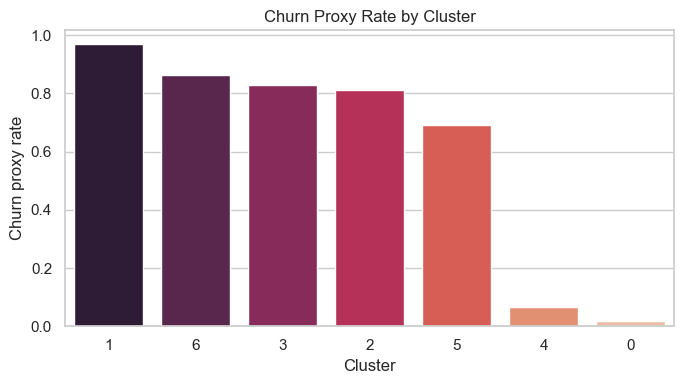

In [12]:
df_churn = df_model.copy()

# Dissatisfaction proxy from target text
# FIX: reset_index on target_text to align with df_churn index after df_model.copy()
target_text_aligned = y_raw.reset_index(drop=True).str.lower()
dissatisfied_mask = target_text_aligned.apply(
    lambda x: any(t in x for t in ["dissatisfied", "unsatisfied", "neutral or dissatisfied", "no", "0", "false"])
)

# Delay stress proxy
high_delay = df_churn["total_delay"].reset_index(drop=True) > df_churn["total_delay"].quantile(0.75)

# Churn proxy: dissatisfied OR high delay
df_churn["churn_proxy"] = (dissatisfied_mask.values | high_delay.values).astype(int)

churn_rate = df_churn["churn_proxy"].mean()
print(f"Estimated churn proxy rate: {churn_rate:.2%}")

plt.figure(figsize=(6, 4))
# FIX: add hue="churn_proxy" + legend=False to avoid seaborn >=0.13 FutureWarning
df_churn["churn_proxy_str"] = df_churn["churn_proxy"].astype(str)
sns.countplot(data=df_churn, x="churn_proxy_str", hue="churn_proxy_str",
              palette="Set2", legend=False)
plt.title("Churn Proxy Distribution")
plt.xlabel("churn_proxy (1 = higher churn risk)")
plt.tight_layout()
plt.show()

# Churn proxy by cluster
df_churn["cluster"] = clusters
cluster_churn = df_churn.groupby("cluster", as_index=False)["churn_proxy"].mean().sort_values("churn_proxy", ascending=False)
display(cluster_churn)

plt.figure(figsize=(7, 4))
# FIX: add hue="cluster" + legend=False to avoid seaborn >=0.13 FutureWarning
cluster_churn["cluster_str"] = cluster_churn["cluster"].astype(str)
sns.barplot(data=cluster_churn, x="cluster_str", y="churn_proxy",
            hue="cluster_str", palette="rocket", legend=False)
plt.title("Churn Proxy Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Churn proxy rate")
plt.tight_layout()
plt.show()


## 11) Business Insights
The following summary is generated from model outputs and segmentation results.

In [13]:
top_features = []
if not importance_df.empty:
    top_features = (
        importance_df.groupby("feature")["importance"].mean().sort_values(ascending=False).head(10).index.tolist()
    )

delay_features_top = [f for f in top_features if "delay" in f.lower() or "arrival" in f.lower() or "departure" in f.lower()]

print("=== Executive Summary ===")
print(f"1) Best predictive model: {best_model_name}")
print("2) Most impactful features (top 10):")
for i, feat in enumerate(top_features, 1):
    print(f"   {i}. {feat}")

if delay_features_top:
    print("3) Delay-related features appear among top drivers:")
    for feat in delay_features_top[:5]:
        print(f"   - {feat}")
else:
    print("3) Delay variables are informative but not dominant in top global drivers.")

worst_cluster = cluster_summary.sort_values("satisfaction_rate").iloc[0]
print("4) Highest-priority segment for intervention:")
print(
    f"   Cluster {int(worst_cluster['cluster'])} with satisfaction rate {worst_cluster['satisfaction_rate']:.2%} "
    f"and avg total delay {worst_cluster['avg_total_delay']:.2f}."
)

high_churn_cluster = cluster_churn.iloc[0]
print("5) Churn-risk focus:")
print(f"   Cluster {int(high_churn_cluster['cluster'])} has highest churn proxy rate ({high_churn_cluster['churn_proxy']:.2%}).")

print("\nRecommended actions:")
print("- Prioritize operational improvements in high-delay journeys.")
print("- Deploy personalized retention offers to high churn-proxy clusters.")
print("- Monitor top feature drivers continuously as service conditions evolve.")

=== Executive Summary ===
1) Best predictive model: Logistic Regression
2) Most impactful features (top 10):
   1. num__0.1
   2. cat__Business_Personal
   3. cat__First-time_First-time
   4. num__3.2
   5. cat__Business.1_Economy
   6. num__3.5
   7. cat__Business_Business
   8. cat__Male_Female
   9. cat__Male_Male
   10. num__5.4
3) Delay variables are informative but not dominant in top global drivers.
4) Highest-priority segment for intervention:
   Cluster 0 with satisfaction rate 100.00% and avg total delay 0.00.
5) Churn-risk focus:
   Cluster 1 has highest churn proxy rate (96.76%).

Recommended actions:
- Prioritize operational improvements in high-delay journeys.
- Deploy personalized retention offers to high churn-proxy clusters.
- Monitor top feature drivers continuously as service conditions evolve.


## 12) Optional Export of Key Outputs

In [14]:
output_dir = Path("outputs_satisfaction")
output_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(output_dir / "model_comparison.csv", index=False)
feature_selection_df.to_csv(output_dir / "feature_importance_selection_stage.csv", index=False)
cluster_summary.to_csv(output_dir / "cluster_summary.csv", index=False)
cluster_churn.to_csv(output_dir / "cluster_churn_proxy.csv", index=False)

if not importance_df.empty:
    importance_df.to_csv(output_dir / "model_feature_importance.csv", index=False)

print(f"Saved outputs to: {output_dir.resolve()}")

Saved outputs to: C:\Users\achre\Downloads\Esprit\DL\SkyInsight\07_ML\Airline Customer Satisfaction\outputs_satisfaction
